# 05_improve_features — Role E: Early-warning feature selection (M3)

**Research question:** Can the project identify at-risk students at enrollment time, before any first- or second-semester outcomes are available?

M3 removes exactly the 12 semester-result features required by the project specification, retains the 24 original enrollment-time features (including the three macroeconomic variables), and uses the same stratified train/test split as every other model.

## 1. Experimental design

- Use `src.data.get_train_test()` once; do not create another split.
- Remove only the six first-semester and six second-semester outcome columns.
- Fit `DecisionTreeClassifier(random_state=42)` without scaling.
- Evaluate M3 through the shared `evaluate_model()` helper.
- Compare M3 with M0 on held-out metrics and feature importance.

The purpose is not to make M3 outperform a model that can see future academic outcomes. The purpose is to quantify the accuracy-versus-timeliness trade-off.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Image, display
from sklearn.tree import DecisionTreeClassifier


def find_repo_root(start: Path | None = None) -> Path:
    """Return the nearest ancestor containing the shared data pipeline."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / "data.py").is_file():
            return candidate
    raise FileNotFoundError("Could not find the repository root containing src/data.py")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data import get_train_test
from src.evaluate import RESULT_COLUMNS, evaluate_model
from src.visualize import plot_tree_figure

FIGURES_DIR = REPO_ROOT / "figures"
OUTPUTS_DIR = REPO_ROOT / "outputs"
RESULTS_PATH = OUTPUTS_DIR / "results.csv"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository: {REPO_ROOT.name}")
print(f"scikit-learn: {sklearn.__version__}")

Repository: Lab2_DecisionTree
scikit-learn: 1.8.0


## 2. Load the shared split and define the excluded features

The feature names below match the released UCI CSV exactly. The raw header is read only to verify the original 36-to-24 feature count; all modeling data still comes from the shared preprocessing and split pipeline.

In [2]:
EARLY_WARNING_EXCLUSIONS = [
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",
]
MACRO_FEATURES = ["Unemployment rate", "Inflation rate", "GDP"]

X_train, X_test, y_train, y_test = get_train_test()

missing_from_train = sorted(set(EARLY_WARNING_EXCLUSIONS) - set(X_train.columns))
missing_from_test = sorted(set(EARLY_WARNING_EXCLUSIONS) - set(X_test.columns))
assert not missing_from_train and not missing_from_test, (missing_from_train, missing_from_test)
assert len(EARLY_WARNING_EXCLUSIONS) == len(set(EARLY_WARNING_EXCLUSIONS)) == 12

X_train_m3 = X_train.drop(columns=EARLY_WARNING_EXCLUSIONS)
X_test_m3 = X_test.drop(columns=EARLY_WARNING_EXCLUSIONS)

raw_header = pd.read_csv(REPO_ROOT / "data" / "raw" / "data.csv", nrows=0).columns.tolist()
original_features = [column for column in raw_header if column != "Target"]
retained_original_features = [
    column for column in original_features if column not in EARLY_WARNING_EXCLUSIONS
]

assert len(original_features) == 36
assert len(retained_original_features) == 24
assert X_train_m3.shape[1] == X_train.shape[1] - 12 == 78
assert X_train_m3.columns.equals(X_test_m3.columns)
assert set(MACRO_FEATURES).issubset(X_train_m3.columns)
assert "International" in X_train_m3.columns

filter_summary = pd.DataFrame({
    "stage": ["Original UCI features", "Early-warning original features",
              "Encoded model columns before filtering", "Encoded M3 columns"],
    "count": [36, len(retained_original_features), X_train.shape[1], X_train_m3.shape[1]],
})
display(filter_summary)
print(f"Train/test rows: {len(X_train):,} / {len(X_test):,}")
print("Retained macroeconomic features:", MACRO_FEATURES)
print("International retained: yes (M3 removes exactly the required 12 columns)")

Train/test rows: 3,539 / 885
Retained macroeconomic features: ['Unemployment rate', 'Inflation rate', 'GDP']
International retained: yes (M3 removes exactly the required 12 columns)


,stage,count
0,Original UCI features,36
1,Early-warning original features,24
2,Encoded model columns before filtering,90
3,Encoded M3 columns,78


## 3. Train M3

M3 intentionally uses the same unconstrained tree configuration as M0. This isolates the effect of feature availability: the only experimental difference is the removal of semester-result information.

In [3]:
m3 = DecisionTreeClassifier(random_state=42)
m3.fit(X_train_m3, y_train)

assert m3.random_state == 42
assert m3.n_features_in_ == X_train_m3.shape[1]
print(f"M3 fitted with {m3.n_features_in_} encoded columns")
print(f"Tree depth: {m3.get_depth()}; leaves: {m3.get_n_leaves()}")

M3 fitted with 78 encoded columns
Tree depth: 30; leaves: 963


## 4. Evaluate M3 on the held-out test set

The shared helper calculates the complete 16-column schema, saves a class-ordered classification report and confusion matrix, and appends M3 idempotently to `outputs/results.csv`.

In [4]:
m3_params = {
    "criterion": "gini",
    "excluded_original_features": EARLY_WARNING_EXCLUSIONS,
    "original_feature_count": 24,
    "random_state": 42,
}

m3_result = evaluate_model(
    m3, X_train_m3, y_train, X_test_m3, y_test,
    model_id="M3",
    model_name="Early-warning Decision Tree (no semester outcomes)",
    params=m3_params,
    author="E",
    classification_report_path=OUTPUTS_DIR / "classification_report_M3.txt",
    confusion_matrix_path=FIGURES_DIR / "E_cm_M3.png",
)
display(pd.DataFrame([m3_result])[RESULT_COLUMNS])

,model_id,model_name,params,train_acc,test_acc,error_rate,precision_macro,recall_macro,f1_macro,roc_auc_macro,recall_dropout,recall_enrolled,recall_graduate,tree_depth,n_leaves,author
0,M3,Early-warning Decision Tree (no semester outco...,"{""criterion"":""gini"",""excluded_original_feature...",1.0,0.541243,0.458757,0.49209,0.49439,0.49305,0.625355,0.53169,0.327044,0.624434,30,963,E


## 5. Present the modified tree

The first four levels are rendered so split names and node statistics remain legible. The display limit does not change the fitted M3 model.

Saved: /workspace/scratch/8c3047868d74/Lab2_DecisionTree/figures/E_tree_M3.png


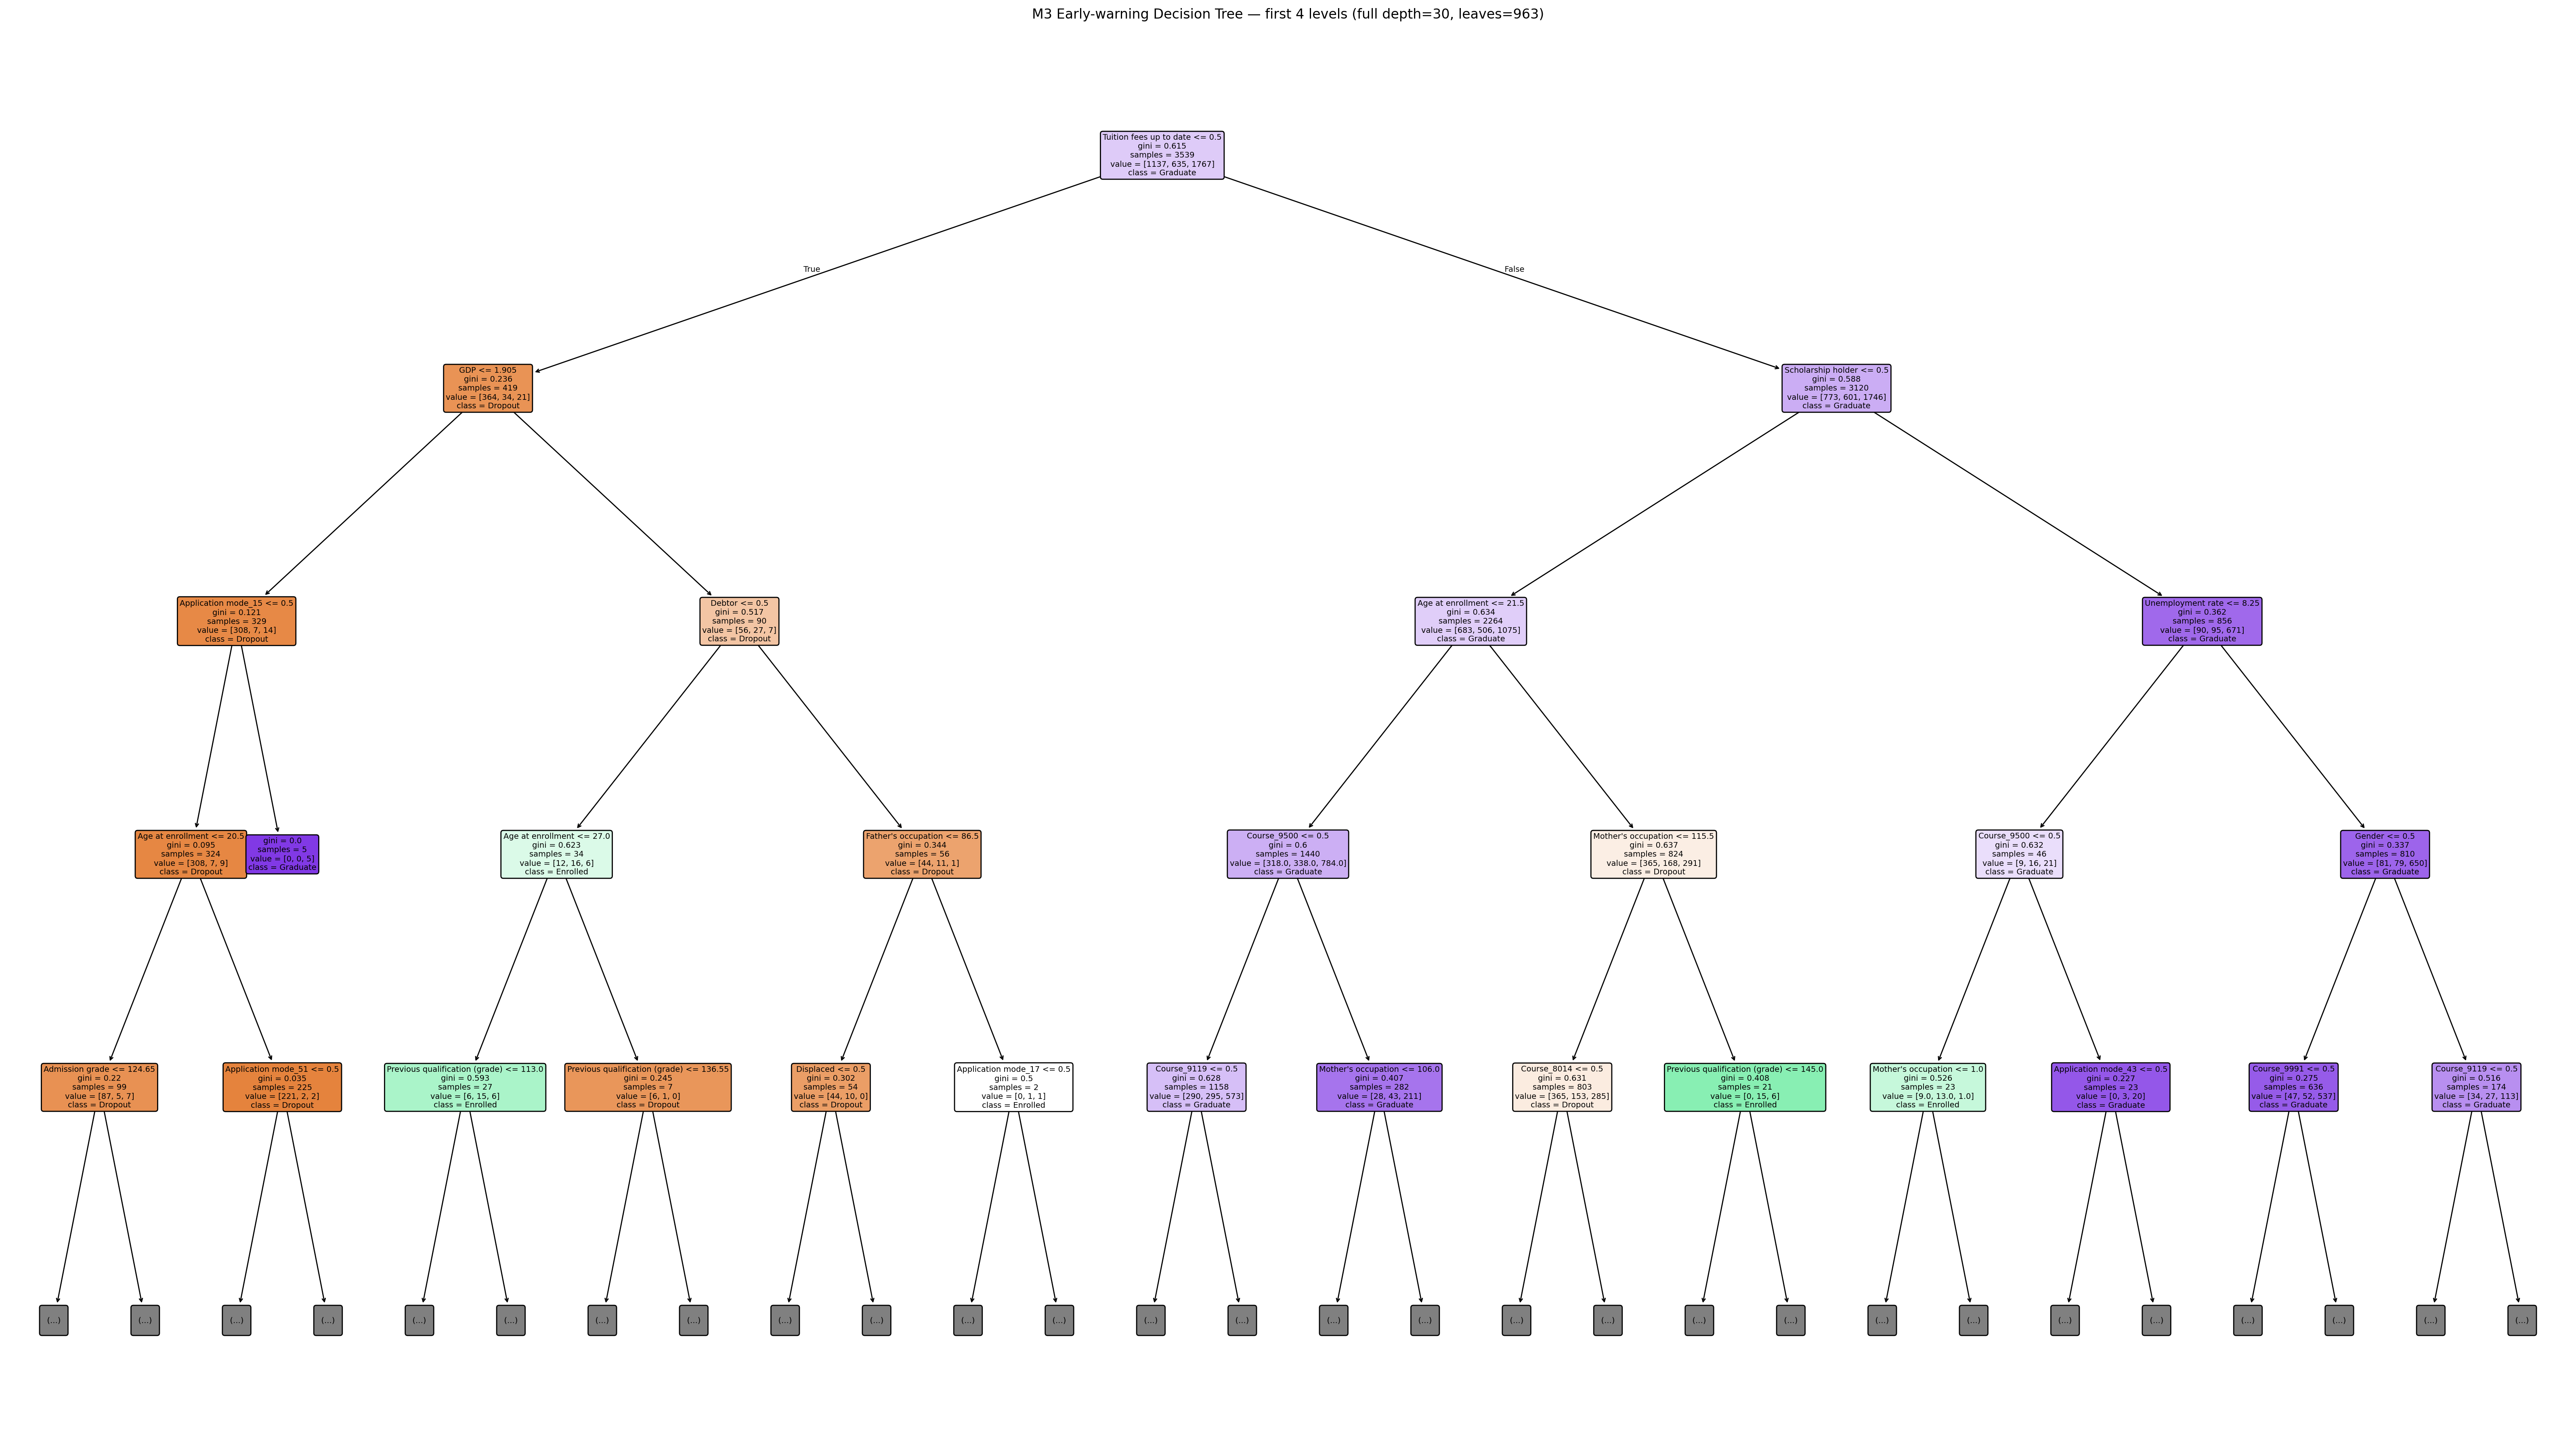

In [5]:
m3_tree_path = plot_tree_figure(
    m3, X_train_m3.columns, m3.classes_,
    FIGURES_DIR / "E_tree_M3.png",
    max_depth=4, figsize=(32, 18), dpi=200, fontsize=7,
    title=(
        "M3 Early-warning Decision Tree — first 4 levels "
        f"(full depth={m3.get_depth()}, leaves={m3.get_n_leaves()})"
    ),
)
print(f"Saved: {m3_tree_path}")
display(Image(filename=str(m3_tree_path), width=1200))

## 6. Compare feature importance: M0 versus M3

A reference M0 is refitted on the same training rows only to recover `feature_importances_`; it is not re-evaluated or added to the result table. M0 can use semester outcomes, whereas every M3 feature is available at or before enrollment.

Saved: /workspace/scratch/8c3047868d74/Lab2_DecisionTree/figures/E_feature_importance.png


,M0 feature,M0 importance,M3 feature,M3 importance
0,Curricular units 2nd sem (approved),0.3404,Admission grade,0.1129
1,Curricular units 2nd sem (grade),0.0453,Tuition fees up to date,0.1116
2,Tuition fees up to date,0.0452,Previous qualification (grade),0.0839
3,Curricular units 2nd sem (enrolled),0.0450,Age at enrollment,0.0790
4,Admission grade,0.0444,Father's occupation,0.0641
5,Curricular units 1st sem (evaluations),0.0335,Mother's occupation,0.0539
6,Previous qualification (grade),0.0308,GDP,0.0466
7,Curricular units 1st sem (approved),0.0288,Mother's qualification,0.0459
8,Mother's occupation,0.0283,Father's qualification,0.0434
9,Curricular units 1st sem (grade),0.0281,Scholarship holder,0.0419


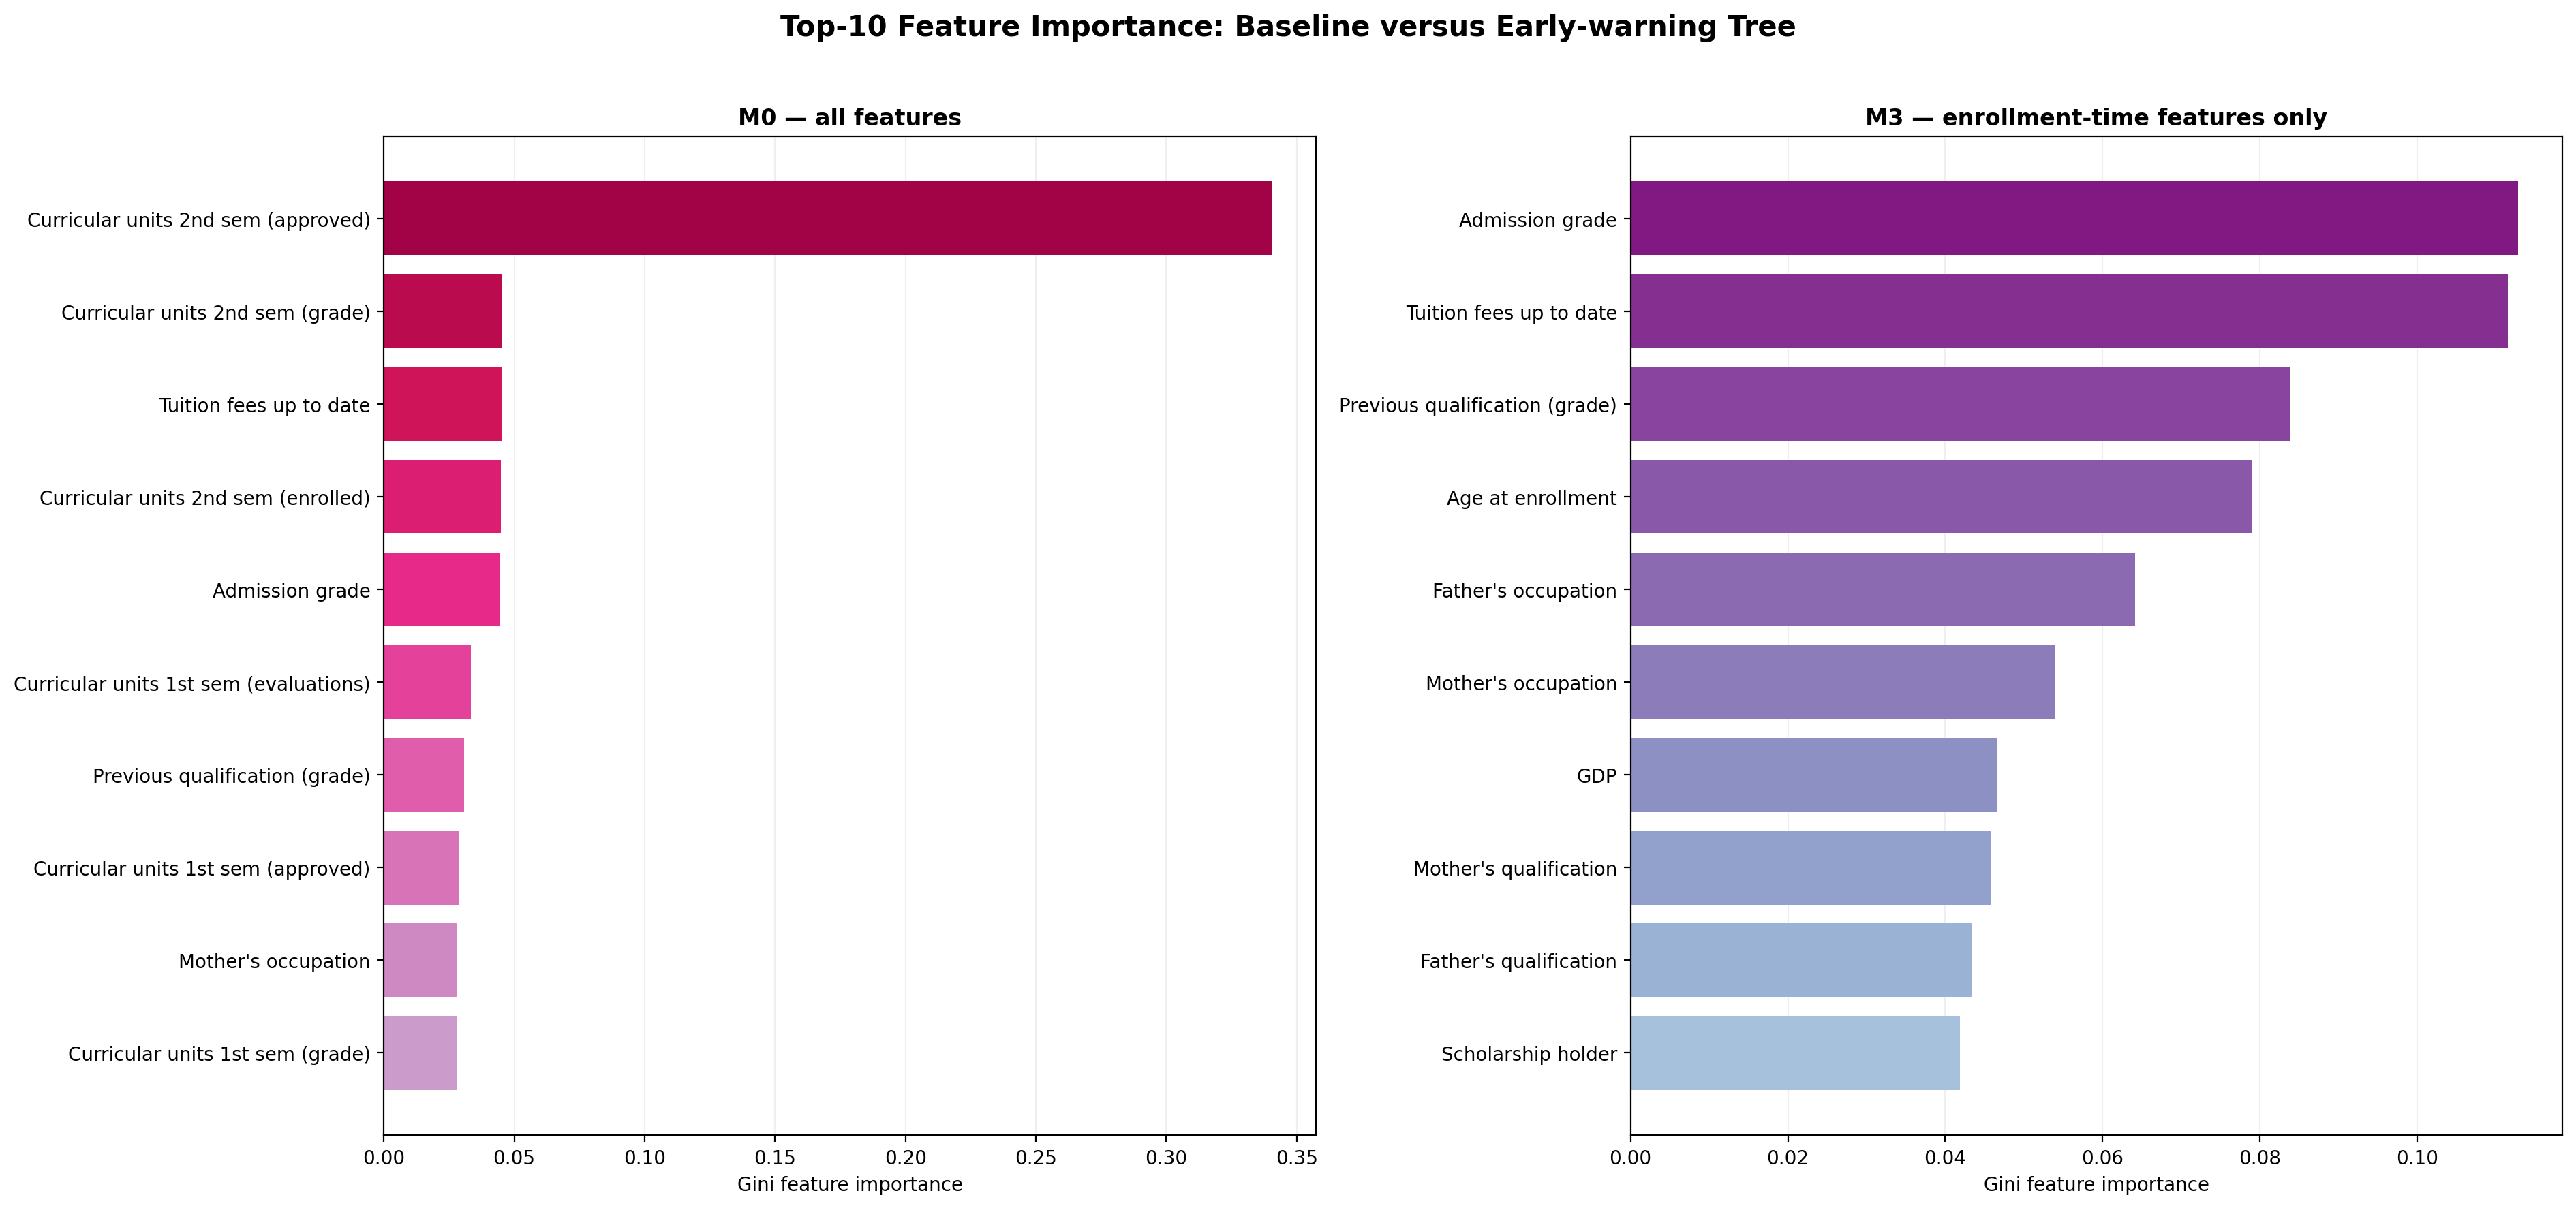

In [6]:
m0_reference = DecisionTreeClassifier(random_state=42)
m0_reference.fit(X_train, y_train)

m0_importance = pd.Series(
    m0_reference.feature_importances_, index=X_train.columns, name="M0 importance"
).sort_values(ascending=False)
m3_importance = pd.Series(
    m3.feature_importances_, index=X_train_m3.columns, name="M3 importance"
).sort_values(ascending=False)

TOP_N = 10
top_m0 = m0_importance.head(TOP_N).sort_values()
top_m3 = m3_importance.head(TOP_N).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(19, 9))
m0_colors = plt.cm.PuRd(np.linspace(0.35, 0.85, TOP_N))
m3_colors = plt.cm.BuPu(np.linspace(0.35, 0.85, TOP_N))
axes[0].barh(top_m0.index, top_m0.values, color=m0_colors)
axes[1].barh(top_m3.index, top_m3.values, color=m3_colors)
axes[0].set_title("M0 — all features", fontweight="bold")
axes[1].set_title("M3 — enrollment-time features only", fontweight="bold")
for axis in axes:
    axis.set_xlabel("Gini feature importance")
    axis.grid(axis="x", alpha=0.2)
    axis.set_axisbelow(True)
fig.suptitle("Top-10 Feature Importance: Baseline versus Early-warning Tree",
             fontsize=15, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96))
feature_importance_path = FIGURES_DIR / "E_feature_importance.png"
fig.savefig(feature_importance_path, dpi=200, bbox_inches="tight", facecolor="white")
plt.close(fig)

importance_table = pd.concat([
    m0_importance.head(TOP_N).reset_index().rename(
        columns={"index": "M0 feature"}
    ),
    m3_importance.head(TOP_N).reset_index().rename(
        columns={"index": "M3 feature"}
    ),
], axis=1)
display(importance_table.style.format({"M0 importance": "{:.4f}", "M3 importance": "{:.4f}"}))
print(f"Saved: {feature_importance_path}")
display(Image(filename=str(feature_importance_path), width=1200))

## 7. Compare M0 and M3

The table reports predictive quality and complexity on the same held-out test rows. The delta is stated in percentage points, not as a relative percentage.

In [7]:
results = pd.read_csv(RESULTS_PATH)
comparison_columns = [
    "train_acc", "test_acc", "error_rate", "precision_macro",
    "recall_macro", "f1_macro", "roc_auc_macro",
    "recall_dropout", "recall_enrolled", "recall_graduate",
    "tree_depth", "n_leaves",
]
comparison = (
    results.loc[results["model_id"].isin(["M0", "M3"])]
    .set_index("model_id")
    .loc[["M0", "M3"], comparison_columns]
)
display(comparison.style.format("{:.4f}"))

m0_row = comparison.loc["M0"]
m3_row = comparison.loc["M3"]
accuracy_delta = float(m3_row["test_acc"] - m0_row["test_acc"])
error_delta = float(m3_row["error_rate"] - m0_row["error_rate"])
f1_delta = float(m3_row["f1_macro"] - m0_row["f1_macro"])

print(f"M0 test accuracy: {m0_row['test_acc']:.4f}")
print(f"M3 test accuracy: {m3_row['test_acc']:.4f}")
print(f"Accuracy change (M3 - M0): {accuracy_delta:+.4f} "
      f"({accuracy_delta * 100:+.2f} percentage points)")
print(f"Error-rate change (M3 - M0): {error_delta:+.4f}")
print(f"Macro-F1 change (M3 - M0): {f1_delta:+.4f}")

M0 test accuracy: 0.6689
M3 test accuracy: 0.5412
Accuracy change (M3 - M0): -0.1277 (-12.77 percentage points)
Error-rate change (M3 - M0): +0.1277
Macro-F1 change (M3 - M0): -0.1152


,train_acc,test_acc,error_rate,precision_macro,recall_macro,f1_macro,roc_auc_macro,recall_dropout,recall_enrolled,recall_graduate,tree_depth,n_leaves
model_id,,,,,,,,,,,,
M0,1.0000,0.6689,0.3311,0.6076,0.6093,0.6083,0.7195,0.6796,0.3836,0.7647,27.0000,634.0000
M3,1.0000,0.5412,0.4588,0.4921,0.4944,0.4931,0.6254,0.5317,0.3270,0.6244,30.0000,963.0000


## 8. Discussion

M0 has an information advantage: its strongest splits can use the number of approved units and grades observed after the student has already completed semesters. Those variables are highly predictive, but they arrive too late for a genuinely preventive intervention.

M3 deliberately accepts lower held-out performance in exchange for earlier availability. Its strongest predictors shift to information known at enrollment, such as admission grade, tuition-fee status, previous-qualification grade, age, socioeconomic indicators, course, and the macroeconomic context. These importance values describe associations in this sample, not causal effects.

Therefore, **the most accurate model is not automatically the most useful model for every application**. M0 is preferable when the task is end-of-year status classification; M3 is the only project model designed for enrollment-time screening. In practice, M3 should support human review and student assistance, not automatic punitive decisions.

In [8]:
classification_report_path = OUTPUTS_DIR / "classification_report_M3.txt"
print("Classification report M3:\n")
print(classification_report_path.read_text(encoding="utf-8"))

Classification report M3:

              precision    recall  f1-score   support

     Dropout     0.5207    0.5317    0.5261       284
    Enrolled     0.3077    0.3270    0.3171       159
    Graduate     0.6479    0.6244    0.6359       442

    accuracy                         0.5412       885
   macro avg     0.4921    0.4944    0.4931       885
weighted avg     0.5459    0.5412    0.5434       885



## 9. Quality gates

These checks prevent silent column mistakes, duplicate result rows, incomplete metrics, and missing deliverables.

In [9]:
final_results = pd.read_csv(RESULTS_PATH)
assert final_results.columns.tolist() == RESULT_COLUMNS
assert (final_results["model_id"] == "M3").sum() == 1
assert m3_result["author"] == "E"
assert np.isclose(m3_result["error_rate"], 1.0 - m3_result["test_acc"])
assert len(EARLY_WARNING_EXCLUSIONS) == 12
assert len(retained_original_features) == 24
assert X_train_m3.shape == (3539, 78)
assert X_test_m3.shape == (885, 78)
assert not (set(EARLY_WARNING_EXCLUSIONS) & set(X_train_m3.columns))
assert set(MACRO_FEATURES).issubset(X_train_m3.columns)
assert "International" in X_train_m3.columns
assert m0_reference.get_depth() == int(m0_row["tree_depth"])
assert m0_reference.get_n_leaves() == int(m0_row["n_leaves"])

required_artifacts = [
    RESULTS_PATH,
    classification_report_path,
    FIGURES_DIR / "E_cm_M3.png",
    m3_tree_path,
    feature_importance_path,
]
missing_or_empty = [
    str(path) for path in required_artifacts
    if not path.is_file() or path.stat().st_size == 0
]
assert not missing_or_empty, f"Missing or empty artifacts: {missing_or_empty}"

print("PASS — exactly 12 semester features removed; 24 original features retained.")
print("PASS — M3 uses the shared split, seed 42, and complete 16-column metrics.")
print("PASS — tree, confusion matrix, classification report, and importance chart exist.")

PASS — exactly 12 semester features removed; 24 original features retained.
PASS — M3 uses the shared split, seed 42, and complete 16-column metrics.
PASS — tree, confusion matrix, classification report, and importance chart exist.


## Conclusion

M3 answers a different operational question from M0: it estimates risk early enough to support intervention. The measured decrease in test accuracy and macro-F1 is the cost of removing information that does not exist at enrollment time. The comparison should therefore report both predictive performance and deployment timing rather than ranking the models by accuracy alone.

### References

1. Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). *Predict Students' Dropout and Academic Success* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89
2. Realinho, V., Machado, J., Baptista, L., & Martins, M. V. (2022). Predicting Student Dropout and Academic Success. *Data, 7*(11), 146. https://doi.org/10.3390/data7110146
3. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
4. Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and Regression Trees*. Wadsworth.